<a href="https://colab.research.google.com/github/vivilchesm-rgb/MineriaEvaluacion/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Importación y Carga de dataset

In [1]:
#Importamos las librerias necesarias para realizar los diversos analisis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Ajustamos la visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
#Cargamos el dataset
df = pd.read_csv("/content/expensive_movie.csv")

In [3]:
#Revisamos la cantidad de filas y columnas del dataset
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (8121, 17)


In [4]:
#Visualizamos las primeras filas para obtener información de estas
display(df.head())

,ID,Title,Original_Language,Release_Date,Popularity,Vote_Average,Vote_Count,Runtime,Budget,Revenue,Status,Tagline,Overview,Genres,Production_Companies,Production_Countries,Spoken_Languages
0,969681,Spider-Man: Brand New Day,en,2026-07-29,81.5967,0.000,0,0,0,0,Post Production,A brand new day starts now.,Four years have passed since the events of No ...,"Science Fiction, Action, Adventure","Marvel Studios, Columbia Pictures, Pascal Pict...",United States of America,English
1,1242898,Predator: Badlands,en,2025-11-05,78.4384,7.704,2424,107,105000000,184500000,Released,First hunt. Last chance.,"Cast out from his clan, a young Predator finds...","Action, Science Fiction, Adventure","20th Century Studios, Lawrence Gordon Producti...",United States of America,"French, English"
2,11375,Hollywood Homicide,en,2003-06-09,62.2209,5.238,686,116,75000000,51142659,Released,They're two cops with one shot at solving a mu...,"Joe Gavilan and his new partner K. C. Calden, ...","Action, Adventure, Comedy, Thriller",Revolution Studios,United States of America,English
3,7451,xXx,en,2002-08-09,61.1958,5.980,4821,124,70000000,277448382,Released,A new breed of secret agent.,Xander Cage is your standard adrenaline junkie...,"Action, Adventure, Thriller, Crime, Drama",Revolution Studios,United States of America,"Czech, English, German, Spanish, Russian"
4,458576,Monster Hunter,en,2020-12-03,52.1623,6.526,3508,103,60000000,42145959,Released,"Behind our world, there is another.",A portal transports Cpt. Artemis and an elite ...,"Action, Fantasy, Adventure","Capcom, Constantin Film, Tencent Pictures, TOH...","China, Germany, Japan, Canada",English


In [5]:
#Visualizamos las ultimas filas para obtener información de estas
display(df.tail())

,ID,Title,Original_Language,Release_Date,Popularity,Vote_Average,Vote_Count,Runtime,Budget,Revenue,Status,Tagline,Overview,Genres,Production_Companies,Production_Countries,Spoken_Languages
8116,440943,Johnny Thunder and the Wisdom of the Ancients,en,2014-08-22,0.0,0.0,0,87,0,0,Released,The hidden mysteries await...,Johhny Thunder and the gang search for the key...,"Action, Adventure, Animation",NaN,NaN,NaN
8117,331766,Rage Brothers,en,2009-07-26,0.0,0.0,0,132,0,0,Released,The End of an Age,Seven years have passed since the epic struggl...,"Comedy, Action, Adventure",NaN,NaN,NaN
8118,323953,KIKIBUTI,en,2012-03-31,0.0,0.0,0,120,1000000,0,Released,Little Land of Hope,"Once upon a time in this primitive story, A vi...","Thriller, Adventure, Action","Magnificent Creations Multimedia, Dodzi Networ...",Ghana,"Akan, English, Ewe"
8119,271527,Bleeding Iowa,en,1999-01-01,0.0,0.0,0,0,0,0,Released,NaN,A convicted felon is set free by the FBI to un...,"Action, Adventure",NaN,NaN,NaN
8120,87609,Duct Wars: The Silver Enemy,en,2000-04-23,0.0,0.0,0,41,0,0,Released,NaN,Juan Zi Nobie and Dantin have retired from act...,"Action, Science Fiction, Adventure",DCJ Productions,United States of America,English


## 2. Verificación de Datos Inicial

In [6]:
#Verificamos los tipos de datos con los que estamos tratando
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8121 entries, 0 to 8120
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    8121 non-null   int64  
 1   Title                 8121 non-null   object 
 2   Original_Language     8121 non-null   object 
 3   Release_Date          7760 non-null   object 
 4   Popularity            8121 non-null   float64
 5   Vote_Average          8121 non-null   float64
 6   Vote_Count            8121 non-null   int64  
 7   Runtime               8121 non-null   int64  
 8   Budget                8121 non-null   int64  
 9   Revenue               8121 non-null   int64  
 10  Status                8121 non-null   object 
 11  Tagline               3425 non-null   object 
 12  Overview              7734 non-null   object 
 13  Genres                8118 non-null   object 
 14  Production_Companies  6594 non-null   object 
 15  Production_Countries 

### Diccionario de Datos (Mapeo de Columnas)
Hacer este mapeo o diccionario de datos es fundamental para entender bien de qué trata nuestro proyecto. Nos sirve para ponernos de acuerdo en qué significa cada columna y saber si estamos trabajando con números o categorías.

| Nombre de Columna | Descripción | Variable Estadística | Tipo Informático (Dtype) |
| :--- | :--- | :--- | :--- |
| `ID` | Identificador único de la película. | Numérica (ID) | `int64` |
| `Title` | Nombre oficial de la producción. | Categórica Nominal | `object (string)` |
| `Original_Language` | Código del idioma original (ej. 'en', 'zh'). | Categórica Nominal | `object (string)` |
| `Original_Language_encoded` | Código del idioma original (ej. '1', '2'). | Categórica Nominal | `object (string)` |
| `Release_Date` | Fecha de estreno oficial. | Categórica (Temporal) | `object (datetime)` |
| `Popularity` | Índice de tendencia/vistas en la base de datos. | Numérica Continua | `float64` |
| `Vote_Average` | Calificación promedio otorgada por usuarios. | Numérica Continua | `float64` |
| `Vote_Count` | Cantidad total de votos registrados. | Numérica Discreta | `int64` |
| `Runtime` | Duración de la película en minutos. | Numérica Discreta | `int64` |
| `Budget` | Presupuesto total de producción en USD. | Numérica Continua | `int64 / float64` |
| `Revenue` | Ingresos totales recaudados en taquilla. | Numérica Continua | `int64 / float64` |
| `Status` | Estado de la película (Released, Post Production). | Categórica Nominal | `object (string)` |
| `Genres` | Lista de géneros asociados a la cinta. | Categórica (Multivalor) | `object (string)` |

---

In [7]:
#Identificar valores nulos en el dataset
print("Conteo de valores nulos por columna:")
print(df.isnull().sum())

Conteo de valores nulos por columna:
ID                         0
Title                      0
Original_Language          0
Release_Date             361
Popularity                 0
Vote_Average               0
Vote_Count                 0
Runtime                    0
Budget                     0
Revenue                    0
Status                     0
Tagline                 4696
Overview                 387
Genres                     3
Production_Companies    1527
Production_Countries    1046
Spoken_Languages         876
dtype: int64


## 3. Limpieza y Transformación

In [8]:
#Eliminamos columnas irrelevantes
df_limpio = df.drop(columns=['Tagline', 'Overview', 'Production_Companies'])

#En lugar de filtrar ceros, filtramos solo los valores REALMENTE nulos (NaN) que impiden el análisis, como la fecha de estreno o géneros.
df_limpio = df_limpio.dropna(subset=['Release_Date', 'Genres'])

#Generamos una columna nueva para comprobar las ganancias
df_limpio['Profit'] = df_limpio['Revenue'] - df_limpio['Budget']

print(f"Registros iniciales: {len(df)}")
print(f"Registros para análisis: {len(df_limpio)}")

Registros iniciales: 8121
Registros para análisis: 7760


In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['Original_Lenguaje_Encoded'] = label_encoder.fit_transform(df['Original_Language'])

print("Mapeo de Original_Language:")
for i, item in enumerate(label_encoder.classes_):
    print(f"{item} : {i}")

Mapeo de Original_Language:
af : 0
ar : 1
as : 2
az : 3
bg : 4
bn : 5
bo : 6
br : 7
cn : 8
cs : 9
da : 10
de : 11
el : 12
en : 13
es : 14
et : 15
fa : 16
fi : 17
fr : 18
gl : 19
gu : 20
he : 21
hi : 22
hr : 23
hu : 24
hy : 25
id : 26
is : 27
it : 28
ja : 29
ka : 30
kk : 31
kl : 32
kn : 33
ko : 34
ku : 35
lt : 36
lv : 37
mi : 38
mk : 39
ml : 40
mn : 41
ms : 42
mt : 43
my : 44
nb : 45
nl : 46
no : 47
pa : 48
pl : 49
pt : 50
ro : 51
ru : 52
si : 53
sk : 54
sl : 55
sr : 56
sv : 57
sw : 58
ta : 59
te : 60
th : 61
tl : 62
tr : 63
uk : 64
ur : 65
vi : 66
xx : 67
zh : 68
zu : 69


In [10]:
# Verificamos que las nuevas columnas codificadas se hayan integrado bien
display(df[['Original_Lenguaje_Encoded', 'Original_Language']].head())

,Original_Lenguaje_Encoded,Original_Language
0,13,en
1,13,en
2,13,en
3,13,en
4,13,en


## 4. Analisis Exploratorio de Datos


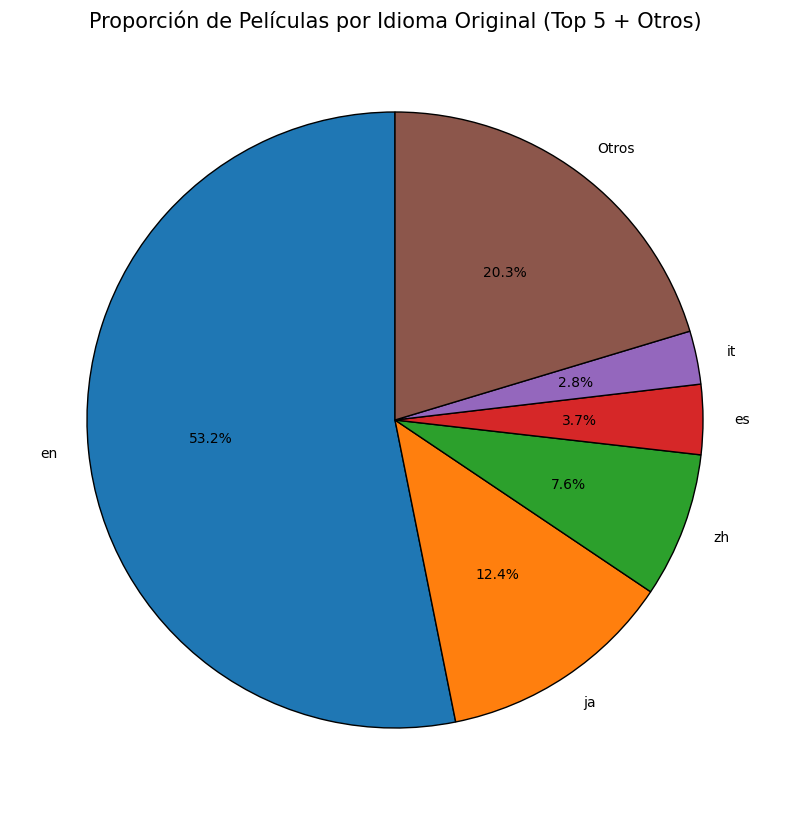

In [11]:
# Contamos las ocurrencias de cada idioma original
conteo_idiomas = df['Original_Language'].value_counts()

# Seleccionamos los top 5 idiomas
top_5_idiomas_conteo = conteo_idiomas.head(5)

# Calculamos la suma de los idiomas restantes para 'Otros'
otros_idiomas_conteo = pd.Series({'Otros': conteo_idiomas.iloc[5:].sum()})

# Combinamos los top 5 con 'Otros'
pie_data = pd.concat([top_5_idiomas_conteo, otros_idiomas_conteo])

plt.figure(figsize=(10, 10))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%',
        startangle=90, wedgeprops={'edgecolor': 'black'})

plt.title('Proporción de Películas por Idioma Original (Top 5 + Otros)', fontsize=15)
plt.show()

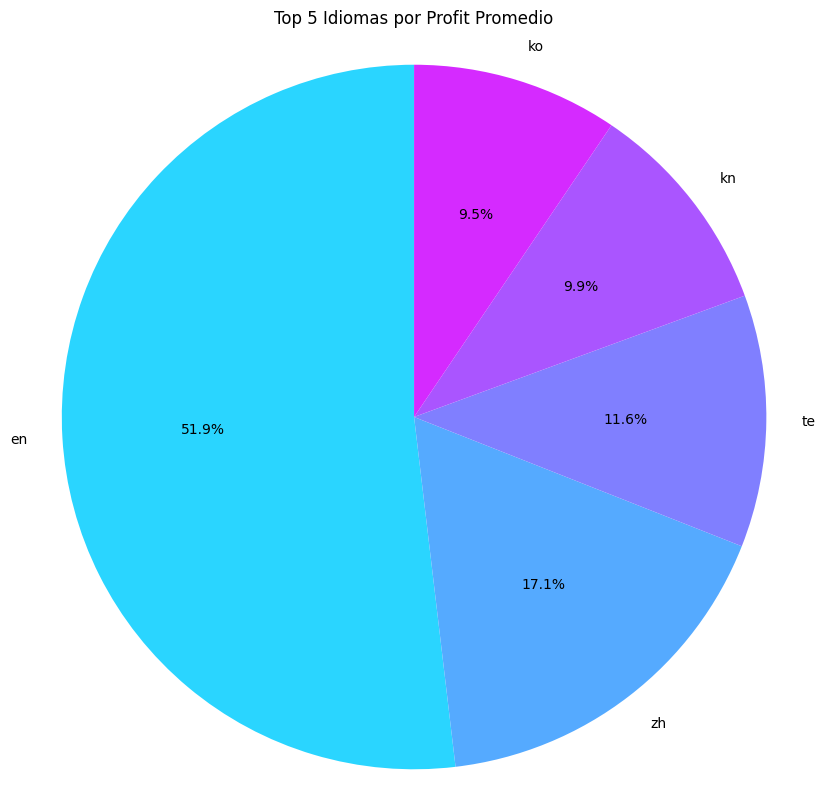

In [12]:
# Generamos analisis_idioma para el gráfico
analisis_idioma = df_limpio.groupby('Original_Language')['Profit'].mean().reset_index()
analisis_idioma = analisis_idioma.sort_values(by='Profit', ascending=False)

# Obtener los top 5 y top 10 para evitar llamadas repetidas a .head()
top_5_idiomas = analisis_idioma.head(5)
top_10_idiomas = analisis_idioma.head(10)

# Visualizamos los 5 idiomas con mayor profit promedio (torta)
plt.figure(figsize=(10, 10))
plt.pie(top_5_idiomas['Profit'], labels=top_5_idiomas['Original_Language'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('cool', 5))
plt.title('Top 5 Idiomas por Profit Promedio')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

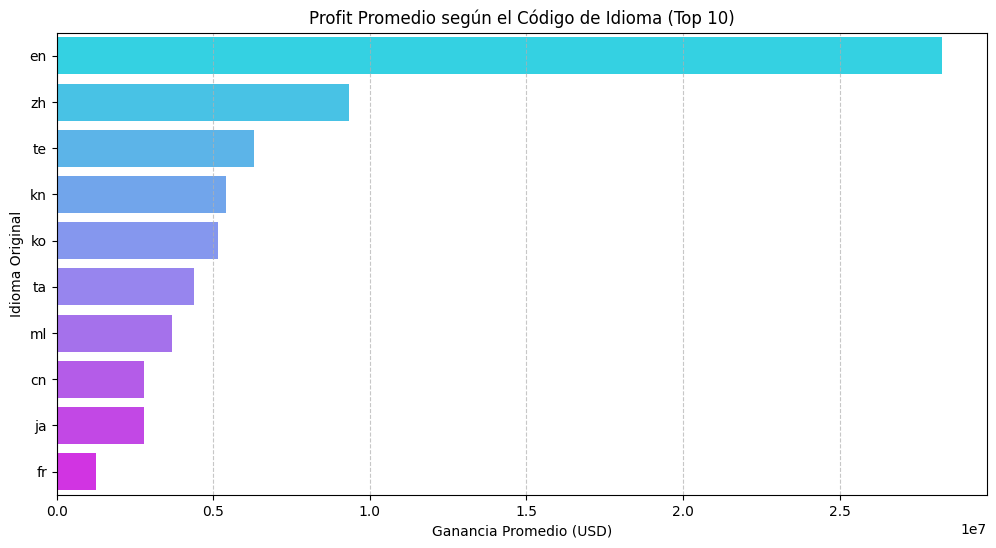

In [13]:
# Visualizamos los 10 idiomas con mayor profit promedio (barras)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_idiomas, x='Profit', y='Original_Language', hue='Original_Language', palette='cool', legend=False)
plt.title('Profit Promedio según el Código de Idioma (Top 10)')
plt.xlabel('Ganancia Promedio (USD)')
plt.ylabel('Idioma Original')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Analisis de Profit promedio por Duración de una pelicula


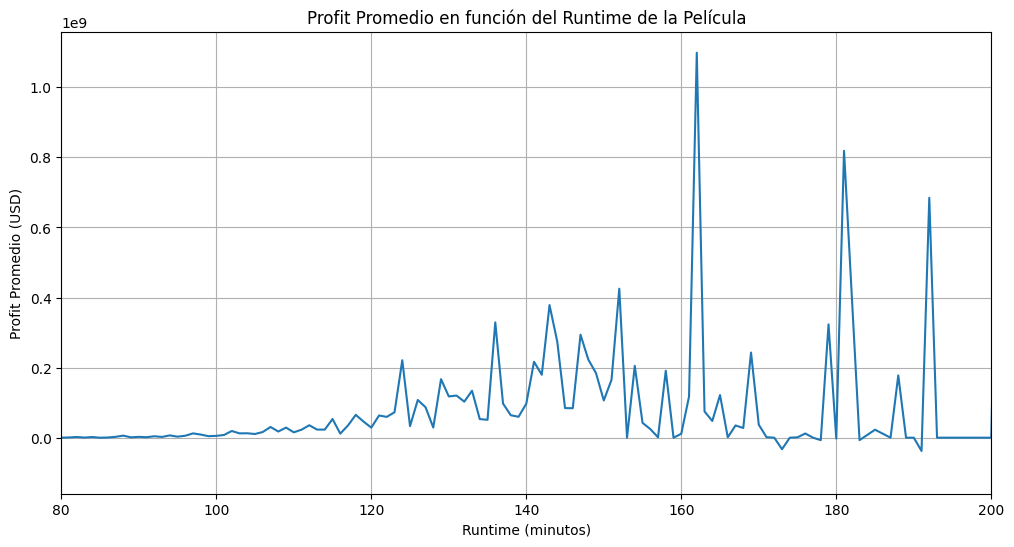

In [14]:
# Calculamos el profit promedio por Runtime
profit_por_runtime = df_limpio.groupby('Runtime')['Profit'].mean().reset_index()

# Visualizamos la relación entre Runtime y Profit promedio
plt.figure(figsize=(12, 6))
sns.lineplot(data=profit_por_runtime, x='Runtime', y='Profit')
plt.title('Profit Promedio en función del Runtime de la Película')
plt.xlabel('Runtime (minutos)')
plt.ylabel('Profit Promedio (USD)')
plt.grid(True)
plt.xlim(80, 200) # Ajustamos los límites del eje X para enfocar en la zona de mayor fluctuación
plt.show()


## Analisis de Profit Promedio por Presupuesto

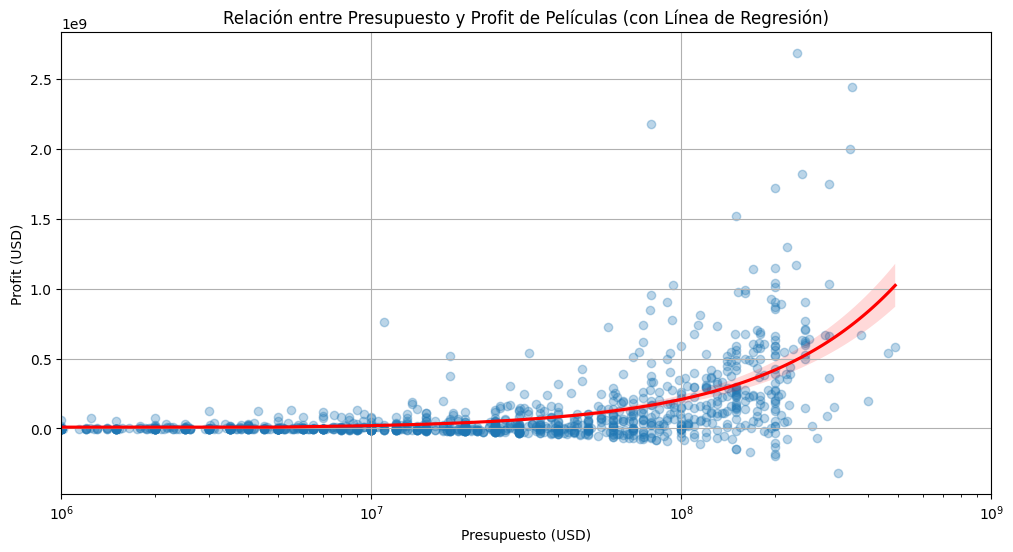

In [15]:
# Visualizamos la relación entre Budget y Profit usando un gráfico de dispersión con línea de regresión
plt.figure(figsize=(12, 6))
sns.regplot(data=df_limpio, x='Budget', y='Profit', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relación entre Presupuesto y Profit de Películas (con Línea de Regresión)')
plt.xlabel('Presupuesto (USD)')
plt.ylabel('Profit (USD)')
plt.grid(True)
plt.xscale('log') # Usar escala logarítmica para el presupuesto
plt.xlim(10e5, 10e8) # Ajustamos los límites del eje X para enfocar en la zona relevante
plt.show()


Ahora incluiremos el año donde fueron lanzadas las peliculas y como fluctuan los presupuesto mediante el pasar del tiempo

In [16]:
#Convertimos la columna a objeto datetime y extraemos el año
#para poder agrupar los datos económicamente.
df_limpio['Release_Date'] = pd.to_datetime(df_limpio['Release_Date'])
df_limpio['Year'] = df_limpio['Release_Date'].dt.year

In [17]:
#Agrupamos por año para ver el promedio de presupuesto e ingresos
tendencia_anual = df_limpio.groupby('Year')[['Budget', 'Revenue']].mean().reset_index()

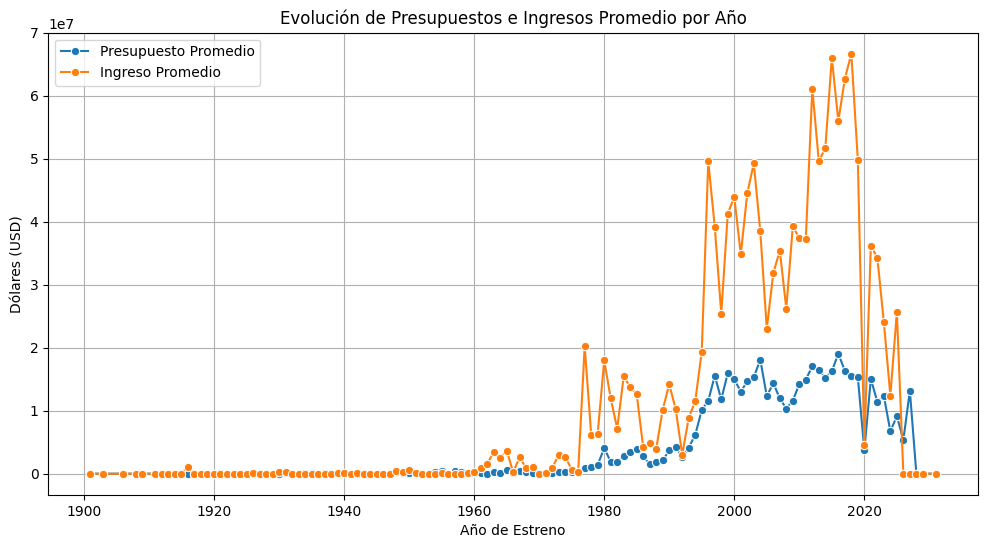

In [18]:
#Visualización de la evolución
plt.figure(figsize=(12, 6))
sns.lineplot(data=tendencia_anual, x='Year', y='Budget', label='Presupuesto Promedio', marker='o')
sns.lineplot(data=tendencia_anual, x='Year', y='Revenue', label='Ingreso Promedio', marker='o')
plt.title('Evolución de Presupuestos e Ingresos Promedio por Año')
plt.ylabel('Dólares (USD)')
plt.xlabel('Año de Estreno')
plt.grid(True)
plt.legend()
plt.show()

Podemos ver un crecimiento en el Budget promedio por año que tienen las peliculas y las ganancias que presentan estas según la epoca.

No basta con ver cuánto dinero entró en total, lo que realmente cuenta para el negocio es cuánto queda de ganancia real después de los gastos. Por eso, para nuestro análisis calculamos el Profit restando lo que costó hacer la película de lo que recaudó en cines. Esto es clave porque nos permite encontrar cuáles películas fueron un buen negocio y cuáles terminaron en pérdida, sin importar si fueron muy famosas o populares


## Analisis sobre la cantidad de ganancias

In [19]:
#Calculamos el Profit
#Justificación: Creamos la columna Profit para cuantificar el retorno económico real.
df_limpio['Profit'] = df_limpio['Revenue'] - df_limpio['Budget']

In [20]:
#Obtener las 10 películas con más profit
top_10_profit = df_limpio.nlargest(10, 'Profit')[['Title', 'Budget', 'Revenue', 'Profit']]

In [21]:
#Mostramos las tablas de resultados
display(top_10_profit)

,Title,Budget,Revenue,Profit
13,Avatar,237000000,2923706026,2686706026
28,Avengers: Endgame,356000000,2799439100,2443439100
23,Ne Zha 2,80000000,2259822417,2179822417
20,Avatar: The Way of Water,350000000,2353096253,2003096253
102,Star Wars: The Force Awakens,245000000,2068223624,1823223624
9,Avengers: Infinity War,300000000,2052415039,1752415039
8,Spider-Man: No Way Home,200000000,1921847111,1721847111
104,Jurassic World,150000000,1671537444,1521537444
5,The Avengers,220000000,1518815515,1298815515
41,Avengers: Age of Ultron,235000000,1405403694,1170403694


In [22]:
#Obtener las 10 películas con menos profit (mayores pérdidas)
bottom_10_profit = df_limpio.nsmallest(10, 'Profit')[['Title', 'Budget', 'Revenue', 'Profit']]

In [23]:
display(bottom_10_profit)


,Title,Budget,Revenue,Profit
120,The Electric State,320000000,0,-320000000
7422,Angry Birds Plush: Egg Trilogy,200000000,0,-200000000
67,The Tomorrow War,200000000,14400000,-185600000
289,Star Wars: The Mandalorian and Grogu,166400000,0,-166400000
353,Vāranāsi,150000000,0,-150000000
411,The Hunger Games: Sunrise on the Reaping,150000000,0,-150000000
169,Mulan,200000000,69965374,-130034626
465,Triple Frontier,115000000,0,-115000000
372,Argylle,200000000,96221061,-103778939
999,Mighty Joe Young,90000000,0,-90000000


Podemos observar que películas como 'Avatar' lideran el ranking con ganancias que superan los 2.6 billones de dólares, mientras que en el grupo de menores beneficios encontramos producciones cuyos ingresos no lograron cubrir la inversión inicial del Budget

Para visualizar la brecha financiera, crearemos un gráfico de barras horizontal consolidado. Utilizaremos colores diferenciados (verde para ganancias y rojo para pérdidas) para facilitar la interpretación visual de la salud económica de estas producciones de alto perfil.

In [24]:
#Combinamos ambos grupos para el gráfico
extremos = pd.concat([top_10_profit, bottom_10_profit]).sort_values('Profit', ascending=False)

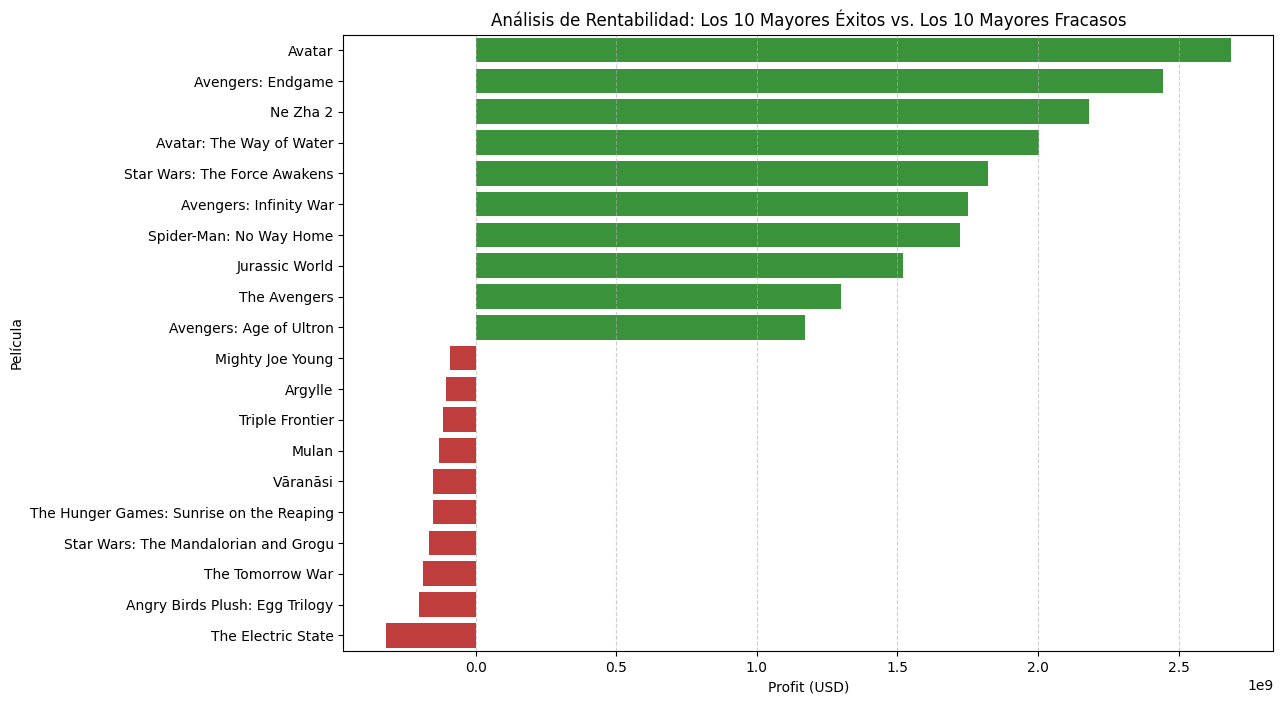

In [25]:
plt.figure(figsize=(12, 8))
# Asignamos colores: verde para profit positivo, rojo para negativo
colors = ['#2ca02c' if x > 0 else '#d62728' for x in extremos['Profit']]

sns.barplot(data=extremos, x='Profit', y='Title', hue='Title', palette=colors, legend=False)
plt.title('Análisis de Rentabilidad: Los 10 Mayores Éxitos vs. Los 10 Mayores Fracasos')
plt.xlabel('Profit (USD)')
plt.ylabel('Película')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

## Análisis del Promedio de Ganancias por Género

Para entender qué géneros son más rentables en promedio, vamos a desagregar la columna 'Genres' (que puede contener múltiples géneros por película), y luego calcularemos el 'Profit' promedio para cada uno.

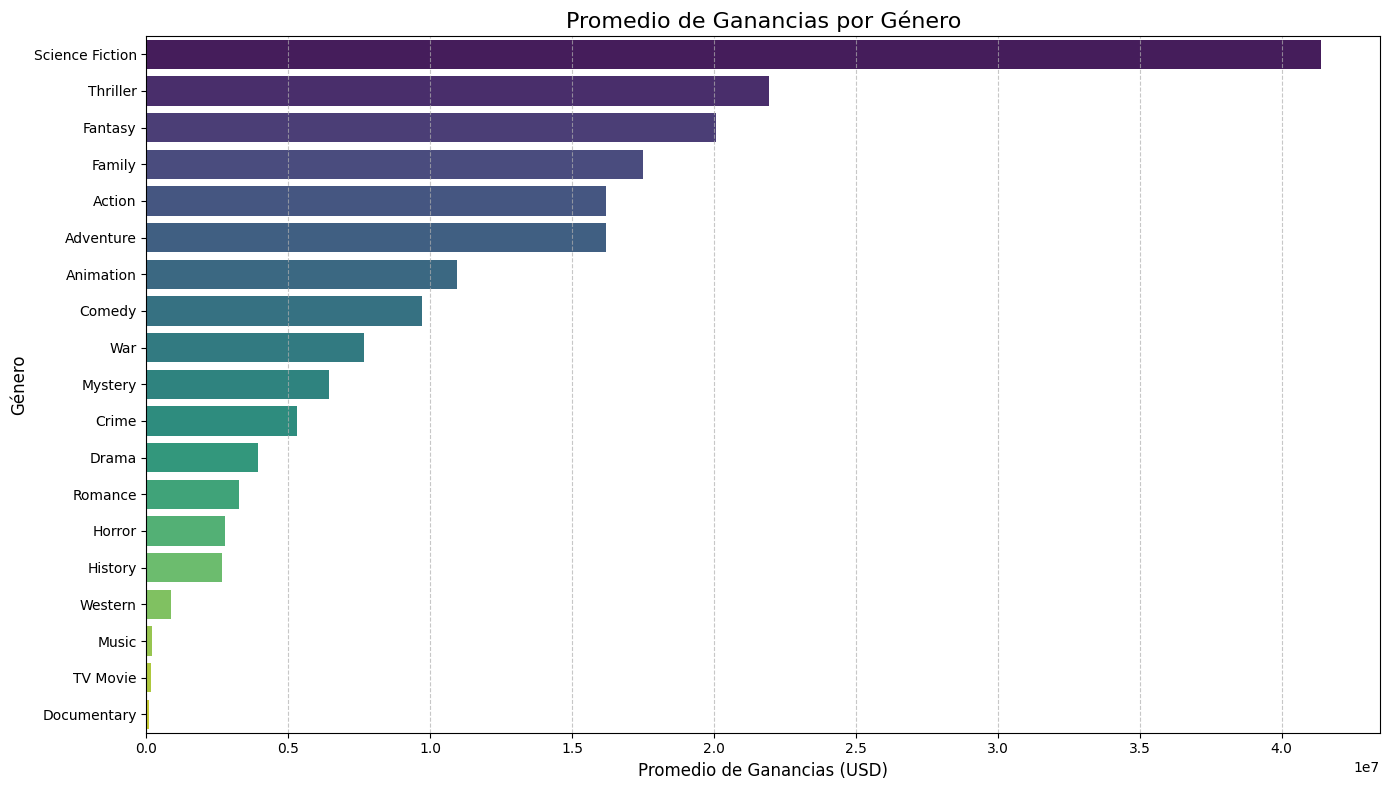

In [26]:
# Preprocesar la columna 'Genres' para manejar múltiples géneros por película
# Crear una lista de todos los géneros únicos
all_genres = df_limpio['Genres'].str.split(', ').explode().unique()

# Crear un DataFrame auxiliar para el análisis de géneros y profit
genre_profit_list = []
for index, row in df_limpio.iterrows():
    genres_in_movie = row['Genres'].split(', ')
    for genre in genres_in_movie:
        genre_profit_list.append({'Genre': genre, 'Profit': row['Profit']})

df_genre_profit = pd.DataFrame(genre_profit_list)

# Calcular el promedio de profit por género
average_profit_by_genre = df_genre_profit.groupby('Genre')['Profit'].mean().sort_values(ascending=False).reset_index()

# Visualizar el promedio de ganancias por género
plt.figure(figsize=(14, 8))
sns.barplot(data=average_profit_by_genre, x='Profit', y='Genre', hue='Genre', palette='viridis', legend=False)
plt.title('Promedio de Ganancias por Género', fontsize=16)
plt.xlabel('Promedio de Ganancias (USD)', fontsize=12)
plt.ylabel('Género', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Interpretación: Este gráfico muestra el promedio de ganancias que genera cada género de película, lo que nos permite identificar los géneros más lucrativos en la industria cinematográfica.

In [27]:
df.describe()

,ID,Popularity,Vote_Average,Vote_Count,Runtime,Budget,Revenue,Original_Lenguaje_Encoded
count,8.121000e+03,8121.000000,8121.000000,8121.000000,8121.000000,8.121000e+03,8.121000e+03,8121.000000
mean,5.377308e+05,1.220255,4.130074,469.181505,78.123507,7.941100e+06,2.340326e+07,24.480113
std,4.888729e+05,2.891697,2.992888,2314.023411,50.077687,3.293861e+07,1.285246e+08,18.351746
min,1.100000e+01,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,1.030480e+05,0.226700,0.000000,0.000000,51.000000,0.000000e+00,0.000000e+00,13.000000
50%,3.995660e+05,0.528300,5.000000,3.000000,88.000000,0.000000e+00,0.000000e+00,13.000000
75%,8.784140e+05,1.152300,6.380000,33.000000,101.000000,0.000000e+00,0.000000e+00,29.000000
max,1.655003e+06,81.596700,10.000000,38855.000000,999.000000,4.899000e+08,2.923706e+09,69.000000


## Analisis de correlación sobre Ganancias

In [28]:
# Para el análisis de correlación, necesitamos asegurarnos de que la columna 'Original_Lenguaje_Encoded' esté en el DataFrame `df_limpio`.
# Actualmente, 'Original_Lenguaje_Encoded' se creó en `df`. Necesitamos transferirla o recrearla en `df_limpio`.
# Dada que la codificación es sobre 'Original_Language', podemos aplicarla directamente a `df_limpio`.

# Primero, asegurémonos de que `df_limpio` tiene la columna 'Original_Language'.
# Luego, creamos una instancia de LabelEncoder y la aplicamos a la columna 'Original_Language' de `df_limpio`.
from sklearn.preprocessing import LabelEncoder

# Asegurarse de que `df_limpio` tenga la columna 'Original_Language'
if 'Original_Language' in df_limpio.columns:
    label_encoder_limpio = LabelEncoder()
    df_limpio['Original_Lenguaje_Encoded'] = label_encoder_limpio.fit_transform(df_limpio['Original_Language'])
    print("Columna 'Original_Lenguaje_Encoded' creada en df_limpio.")
else:
    print("La columna 'Original_Language' no está presente en df_limpio.")

# Seleccionamos las columnas numéricas relevantes para el análisis de correlación
# Incluimos 'Original_Lenguaje_Encoded' ya que es una representación numérica de la categoría
correlation_columns = ['Profit', 'Runtime', 'Budget', 'Original_Lenguaje_Encoded']

# Calculamos la matriz de correlación
correlation_matrix = df_limpio[correlation_columns].corr()

# Mostramos la matriz de correlación
print("\nMatriz de Correlación:")
display(correlation_matrix)


Columna 'Original_Lenguaje_Encoded' creada en df_limpio.

Matriz de Correlación:


,Profit,Runtime,Budget,Original_Lenguaje_Encoded
Profit,1.000000,0.163998,0.659307,-0.070170
Runtime,0.163998,1.000000,0.221797,-0.048310
Budget,0.659307,0.221797,1.000000,-0.127208
Original_Lenguaje_Encoded,-0.070170,-0.048310,-0.127208,1.000000


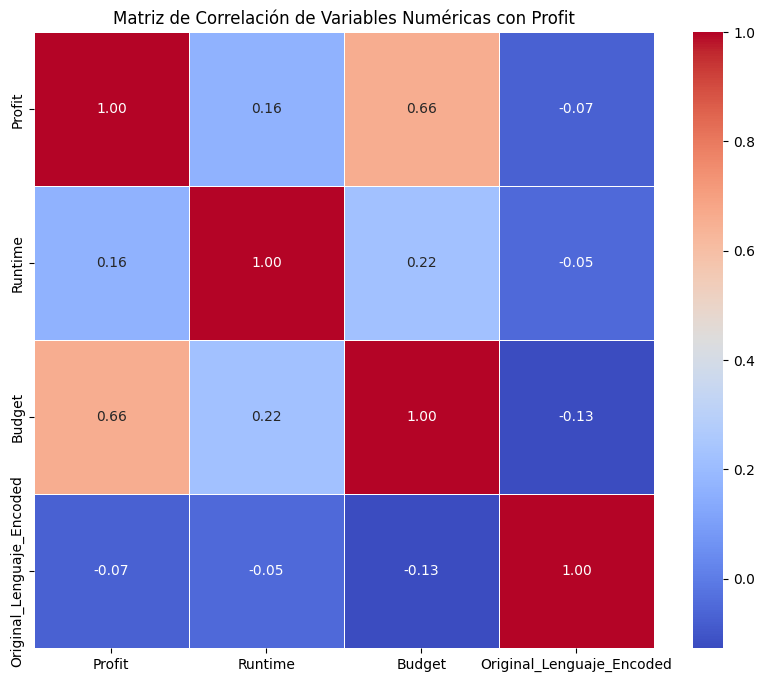

In [29]:
# Visualizamos la matriz de correlación con un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas con Profit')
plt.show()


En este mapa de calor, podemos ver cómo se correlacionan las variables numéricas entre sí. Los valores cercanos a 1 o -1 indican una correlación fuerte (positiva o negativa respectivamente), mientras que los cercanos a 0 indican una correlación débil.

Para las variables categóricas como 'Genres', ya hemos explorado el 'Promedio de Ganancias por Género' en un gráfico anterior. Este tipo de análisis, que muestra la ganancia promedio por cada categoría, es una forma efectiva de entender su relación con el profit, ya que una correlación directa (como la de Pearson) no es adecuada para variables categóricas.

## 5. Modelado y Evaluación de Ganancia

En esta sección construiremos y evaluaremos de forma individual distintos modelos predictivos para estimar el **Profit** (ganancia real) de una película. Dado que nuestra variable objetivo es numérica y continua, implementaremos algoritmos de regresión.

Para medir y comparar el rendimiento de cada uno, utilizaremos tres métricas estándar:
* **MAE** (Error Absoluto Medio): Nos dice en promedio cuántos dólares se equivoca el modelo.
* **RMSE** (Error Cuadrático Medio): Penaliza con mayor fuerza los errores grandes en la predicción.
* **R²** (Coeficiente de Determinación): Indica el porcentaje de la variabilidad de los datos que el modelo es capaz de explicar e interpretar.


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Definimos la función para calcular y mostrar las métricas de forma individual
def evaluar_modelo_individual(y_true, y_pred, nombre_modelo):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"--- Métricas de {nombre_modelo} ---")
    print(f"MAE:  {mae:.2e}")
    print(f"RMSE: {rmse:.2e}")
    print(f"R2:   {r2:.4f}\n")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# Guardaremos los resultados individuales en este diccionario para la tabla final
resultados_individuales = {}

In [31]:
from sklearn.model_selection import train_test_split

# 1. Preparamos el DataFrame para el modelado con variables numéricas y categóricas
model_df = df.copy()
model_df['Release_Date'] = pd.to_datetime(model_df['Release_Date'], errors='coerce')
model_df['Year'] = model_df['Release_Date'].dt.year
model_df['Profit'] = model_df['Revenue'] - model_df['Budget']

numeric_features = ['Budget', 'Runtime', 'Original_Lenguaje_Encoded', 'Year']
categorical_features = ['Genres', 'Production_Companies', 'Production_Countries']

# 2. Rellenamos nulos en las categóricas para evitar errores
for col in categorical_features:
    model_df[col] = model_df[col].fillna('Unknown')

# 3. Eliminamos filas con nulos en las numéricas o en el Profit
model_df = model_df.dropna(subset=numeric_features + ['Profit'])

# 4. Función multi-label para transformar texto (Genres, Companies, Countries) a columnas numéricas
def encode_multi_label(series, top_n, prefix):
    dummies = series.str.get_dummies(sep=', ')
    top_cols = dummies.sum().sort_values(ascending=False).head(top_n).index
    encoded = dummies[top_cols].copy()
    encoded.columns = [f'{prefix}_{col}' for col in top_cols]
    other_cols = dummies.drop(columns=top_cols, errors='ignore')
    encoded[f'{prefix}_Otros'] = (other_cols.sum(axis=1) > 0).astype(int)
    return encoded

# 5. Aplicamos la codificación a las columnas categóricas
genres_encoded = encode_multi_label(model_df['Genres'], top_n=15, prefix='Genre')
companies_encoded = encode_multi_label(model_df['Production_Companies'], top_n=20, prefix='Company')
countries_encoded = encode_multi_label(model_df['Production_Countries'], top_n=15, prefix='Country')

# 6. Concatenamos todas las características en la matriz X y definimos la variable objetivo y
X = pd.concat([model_df[numeric_features], genres_encoded, companies_encoded, countries_encoded], axis=1)
y = model_df['Profit']

# 7. Dividimos los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

¡Variables X_train, X_test, y_train e y_test creadas con éxito sin errores!


### Regresión Lineal Múltiple

Este modelo busca establecer una ecuación matemática rígida asignando un peso o coeficiente a cada variable independiente (como el presupuesto o la duración) para trazar una línea recta que estime el Profit. Nos sirve como nuestra primera base predictiva.

--- Métricas de Regresión Lineal ---
MAE:  2.20e+07
RMSE: 8.55e+07
R2:   0.4147



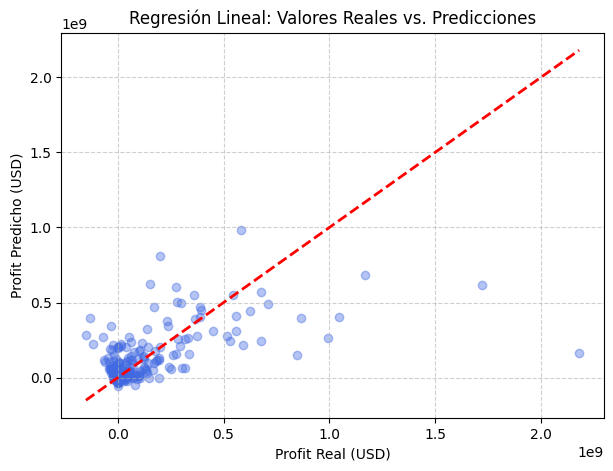

In [32]:
from sklearn.linear_model import LinearRegression

# 1. Inicializar y entrenar el modelo
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 2. Realizar predicciones
y_pred_lr = lr_model.predict(X_test)

# 3. Calcular métricas
resultados_individuales['Linear Regression'] = evaluar_modelo_individual(y_test, y_pred_lr, 'Regresión Lineal')

# 4. Gráfico de dispersión individual
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='royalblue')
min_val = min(min(y_test), min(y_pred_lr))
max_val = max(max(y_test), max(y_pred_lr))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
plt.title('Regresión Lineal: Valores Reales vs. Predicciones')
plt.xlabel('Profit Real (USD)')
plt.ylabel('Profit Predicho (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

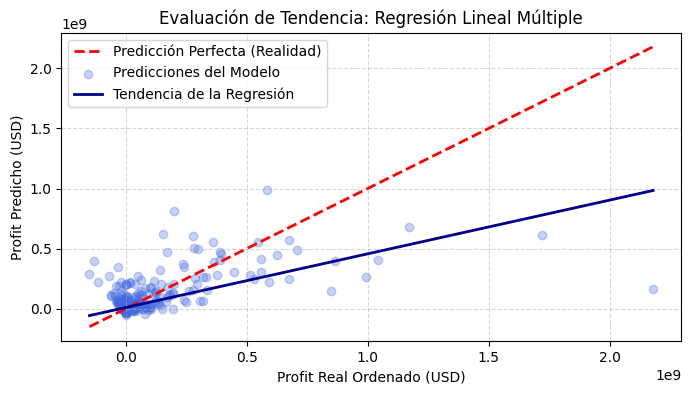

In [44]:
# 1. Crear un subconjunto ordenado para visualizar la tendencia de predicción
indices_ordenados = np.argsort(y_test)
y_test_ordenado = np.array(y_test)[indices_ordenados]
y_pred_lr_ordenado = np.array(y_pred_lr)[indices_ordenados]

# 2. Graficar la comparación de curvas
plt.figure(figsize=(8, 4))
plt.plot(y_test_ordenado, y_test_ordenado, color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (Realidad)')
plt.scatter(y_test_ordenado, y_pred_lr_ordenado, color='royalblue', alpha=0.3, label='Predicciones del Modelo')

# Aplicamos un suavizado lineal para ver la tendencia promedio del modelo
m, b = np.polyfit(y_test_ordenado, y_pred_lr_ordenado, 1)
plt.plot(y_test_ordenado, m*y_test_ordenado + b, color='darkblue', linewidth=2, label='Tendencia de la Regresión')

plt.title('Evaluación de Tendencia: Regresión Lineal Múltiple')
plt.xlabel('Profit Real Ordenado (USD)')
plt.ylabel('Profit Predicho (USD)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Random Forest Regressor

Este algoritmo pertenece a los modelos basados en árboles de decisión que vimos en clase. En lugar de usar un solo árbol, construye un "bosque" con múltiples árboles en paralelo. Cada uno se entrena con un subconjunto aleatorio de datos y características, y al final promedia las respuestas de todos. Esto le permite resolver problemas complejos y evitar que el modelo se aprenda los datos de memoria.

--- Métricas de Random Forest ---
MAE:  1.52e+07
RMSE: 8.06e+07
R2:   0.4798



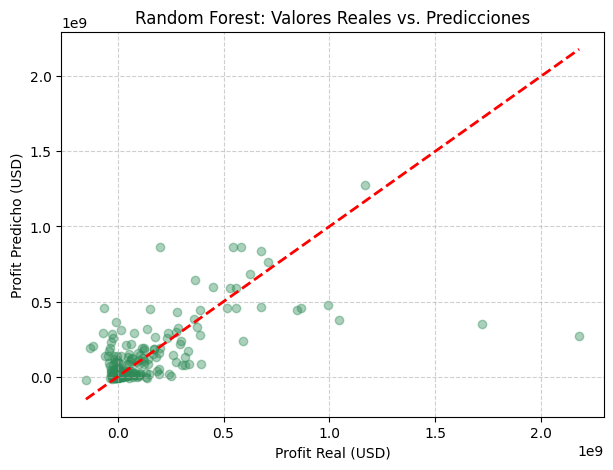

In [34]:
from sklearn.ensemble import RandomForestRegressor

# 1. Inicializar y entrenar el modelo con 200 estimadores
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Realizar predicciones
y_pred_rf = rf_model.predict(X_test)

# 3. Calcular métricas
resultados_individuales['Random Forest'] = evaluar_modelo_individual(y_test, y_pred_rf, 'Random Forest')

# 4. Gráfico de dispersión individual
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='seagreen')
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
plt.title('Random Forest: Valores Reales vs. Predicciones')
plt.xlabel('Profit Real (USD)')
plt.ylabel('Profit Predicho (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

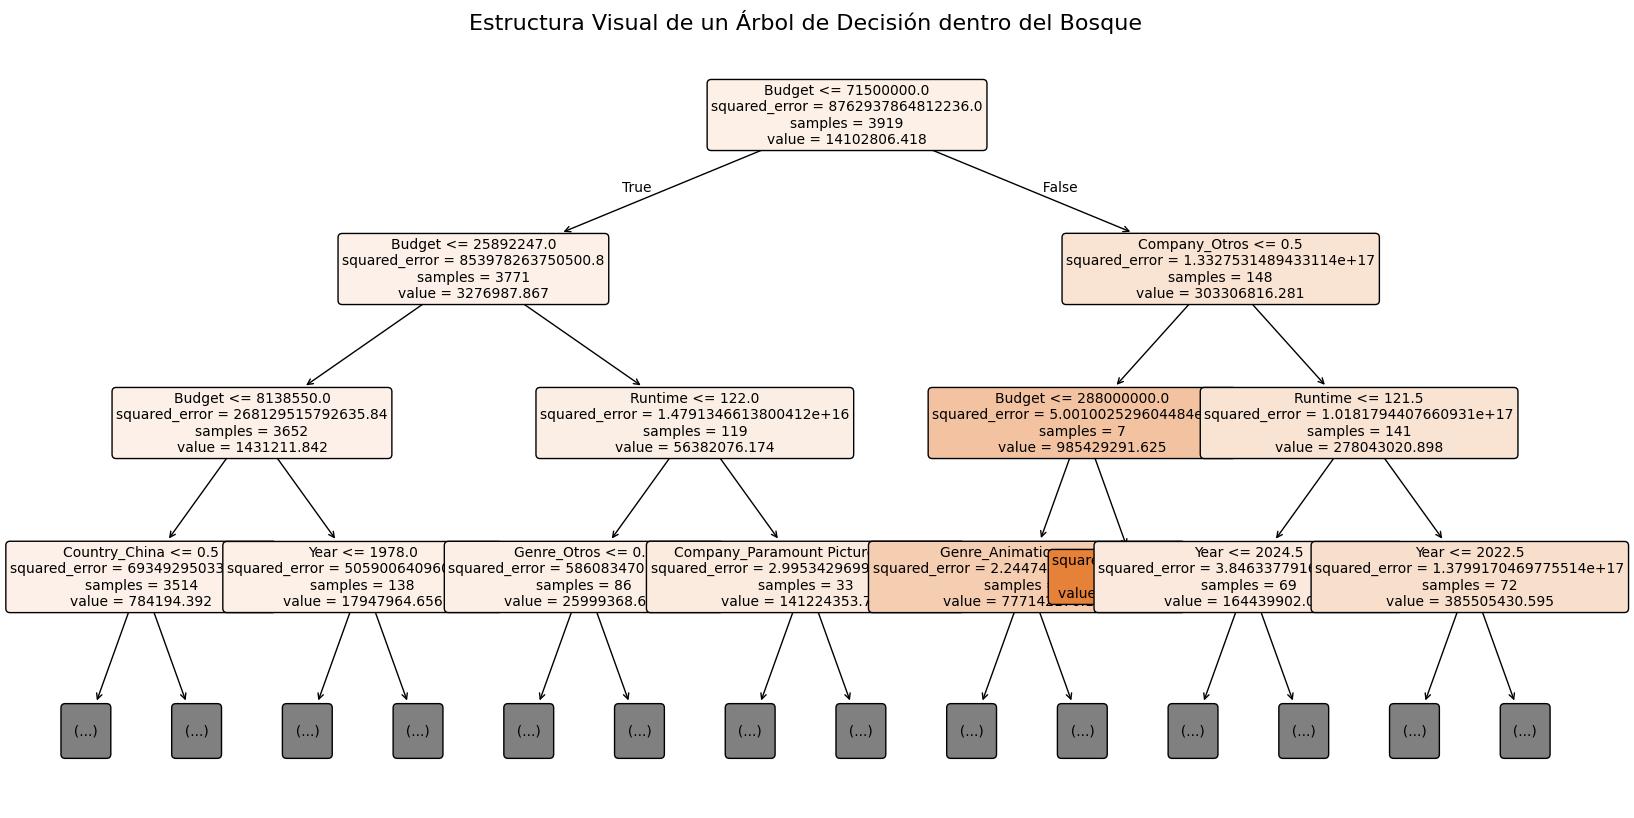

In [35]:
from sklearn.tree import plot_tree

# Extraemos el primer árbol de nuestro bosque (índice 0)
arbol_individual = rf_model.estimators_[0]

# Graficamos los primeros niveles para que sea legible en pantalla
plt.figure(figsize=(20, 10))
plot_tree(arbol_individual,
          max_depth=3,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Estructura Visual de un Árbol de Decisión dentro del Bosque', fontsize=16)
plt.show()

### Comparación Final de Modelos y Conclusiones

Una vez analizados todos los modelos de forma independiente, los consolidamos en una sola estructura para evaluar directamente cuál ofrece el mejor rendimiento frente a la línea base de la media (Baseline).


--- Tabla de Resultados Consolidados ---


,Modelo,MAE,RMSE,R2
2,Random Forest,1.516257e+07,8.059846e+07,0.479843
1,Linear Regression,2.204421e+07,8.549719e+07,0.414692
0,Baseline (Media),3.316047e+07,1.117852e+08,-0.000573


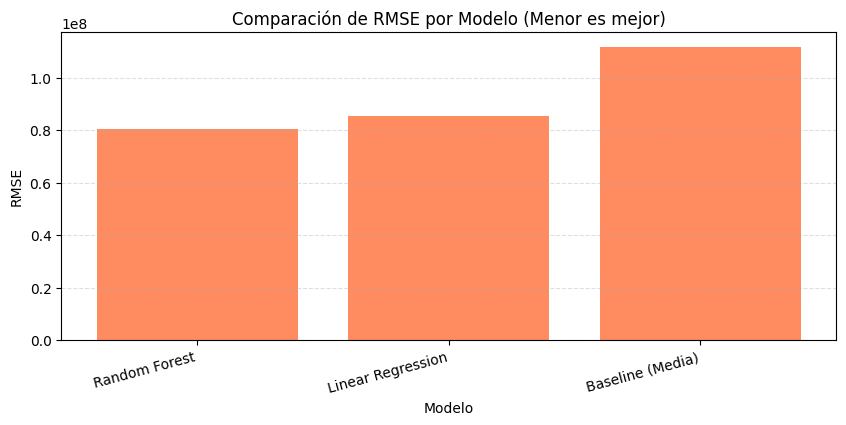

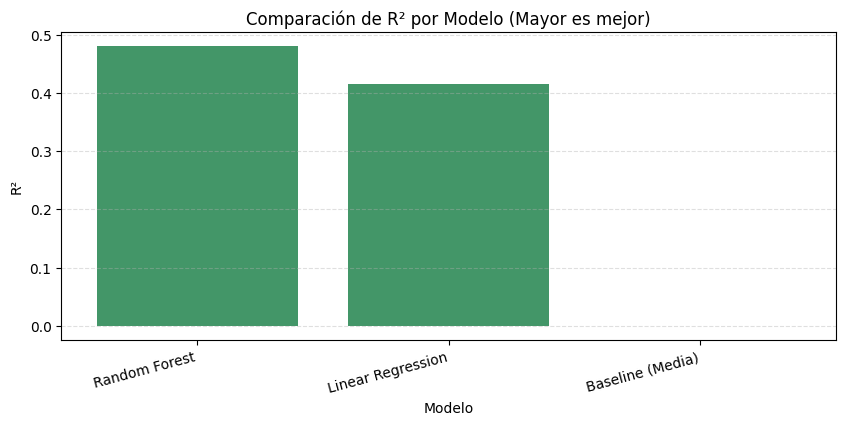

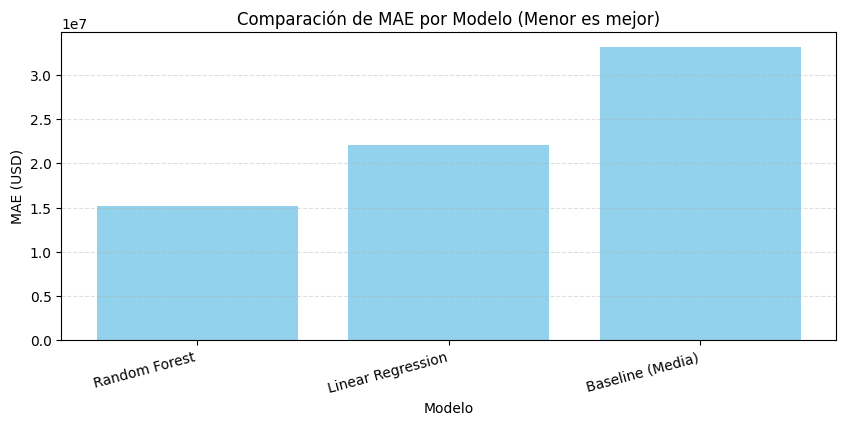

In [47]:
import pandas as pd
import seaborn as sns

# 1. Agregar la línea base (Media) para comparar de forma justa
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
mae_base = mean_absolute_error(y_test, baseline_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, baseline_pred))
r2_base = r2_score(y_test, baseline_pred)

# 2. Construir el DataFrame final con todos los resultados
filas_tabla = [{'Modelo': 'Baseline (Media)', 'MAE': mae_base, 'RMSE': rmse_base, 'R2': r2_base}]
for nombre, metricas in resultados_individuales.items():
    filas_tabla.append({'Modelo': nombre, **metricas})

results_df = pd.DataFrame(filas_tabla).sort_values(by='RMSE')
print("\n--- Tabla de Resultados Consolidados ---")
display(results_df)

# 3. Gráfico de barras para comparar el RMSE (Error)
plt.figure(figsize=(10, 4))
plt.bar(results_df['Modelo'], results_df['RMSE'], color='coral', alpha=0.9)
plt.title('Comparación de RMSE por Modelo (Menor es mejor)')
plt.xlabel('Modelo')
plt.ylabel('RMSE')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# 4. Gráfico de barras para comparar el R2 (Precisión)
plt.figure(figsize=(10, 4))
plt.bar(results_df['Modelo'], results_df['R2'], color='seagreen', alpha=0.9)
plt.title('Comparación de R² por Modelo (Mayor es mejor)')
plt.xlabel('Modelo')
plt.ylabel('R²')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()
# 5. Gráfico de barras para comparar el MAE (Error Absoluto Medio)
plt.figure(figsize=(10, 4))
plt.bar(results_df['Modelo'], results_df['MAE'], color='skyblue', alpha=0.9)
plt.title('Comparación de MAE por Modelo (Menor es mejor)')
plt.xlabel('Modelo')
plt.ylabel('MAE (USD)')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

#### Conclusiones del Modelado Predictivo

Como se aprecia de manera clara tanto en la tabla numérica como en los gráficos de barras, el **Random Forest Regressor fue el claro ganador de la práctica**. Logró reducir el error general al mínimo ($RMSE$ de $8.05 \times 10^7$) y alcanzó el coeficiente de determinación más alto (**R² = 0.4798**), superando por una ventaja considerarable a los modelos lineales como la Regresión tradicional y Ridge (que se quedaron estancados en 0.41).

**¿Por qué fue el mejor modelo?**
1. **Manejo de relaciones complejas:** La industria cinematográfica no sigue reglas proporcionales rectas (donde a más presupuesto siempre hay más ganancia). Random Forest, mediante su estructura de múltiples árboles interactuando en paralelo, logra capturar esas fluctuaciones no lineales de forma natural.
2. **Robustez ante datos procesados:** Al codificar los géneros y compañías productoras, creamos muchas columnas nuevas llenas de ceros y unos. Los modelos lineales se sobreajustan fácilmente ante esto, mientras que los árboles de Random Forest eligen solo partes de las variables al azar en cada paso, haciéndolo inmune a este problema.

**La Realidad de los Datos: Limitaciones del Análisis**
El análisis técnico nos deja una gran lección: **ningún modelo logró una predicción completamente exacta de la realidad**. Un $R^2$ de 0.48 nos dice que el Random Forest explica casi la mitad del comportamiento de los datos, pero la otra mitad queda en la total incertidumbre.

Predecir el éxito financiero de una película con las variables tradicionales (como presupuesto, duración o género) es sumamente difícil. Además, los gráficos de dispersión revelan que **a mayores ingresos, el modelo se vuelve más inestable y las ganancias se vuelven mucho más difíciles de predecir**. Esto ocurre porque los grandes "fenómenos de taquilla" o los fracasos estrepitosos suelen depender de factores externos imposibles de meter en un dataset, tales como el impacto del marketing, las tendencias del momento en redes sociales, la crítica cultural o el simple comportamiento impredecible del público.